# Comprendre numpy

Numpy est un package python qui permet de manipuler des tableaux multidimensionnels. Il est très utilisé dans le domaine scientifique et de l'apprentissage automatique. Il est très rapide car il est écrit en C et utilise des algorithmes optimisés pour les opérations sur les tableaux.

Dans tout ce qui suit, nous importerons numpy de la façon suivante :

In [2]:
import numpy as np

## Création d'un tableau
Il existe plusieurs fonctions pour créer un tableau numpy : ```array``` (création à partir d'une liste), ```zeros```, ```ones```, ```arange``` (même comportement que range), ```linspace```, ```logspace```. On peut aussi créer des tableaux aléatoires : ```np.random.rand```, ```np.random.normal```.

Donner un exemple de chacune de ces fonctions.

In [3]:
print(np.array([1, 2]))
print(np.zeros(10))
print(np.ones(1))
print(np.arange(10))
print(np.linspace(0, 1, 10))
print(np.random.rand(10))
print(np.random.normal(loc=10, scale=.2, size=30))


[1 2]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1.]
[0 1 2 3 4 5 6 7 8 9]
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[0.94838321 0.03619978 0.72036657 0.81649895 0.3685612  0.88454938
 0.93757534 0.82834611 0.22956835 0.70419021]
[ 9.86099931 10.18574018  9.95691189 10.14533145 10.18353052  9.83565
  9.81968203  9.53957946 10.30407312  9.59610441 10.13512165 10.57129618
  9.74782276 10.06521668 10.37150672  9.84973126 10.06020121  9.9931244
  9.7615218  10.12002514  9.97172372 10.15467195 10.01642075 10.39320599
 10.01566197  9.69726345  9.87462398 10.09574079  9.94123063 10.05172576]


* Fonction linspace qu'est ce qui est affiché avec la fonction ```np.linspace(0, 1, 10)``` ? Pourquoi ? Utiliser l'argument optionnel ```endpoint``` pour créer le tableau de 10 points ```[0, 0.1, 0.2, ..., 0.9]```


## Exemples de manipulation de tableaux

* Avec numpy, calculer $\sum_k \frac{1}{k^2}$ de 1 à $100\,000$ et comparer à la valeur théorique de la limite qui est $\pi^2/6$. On utilisera la fonction ```np.arange``` (en commençant le tableau à 1) et ```np.sum```. Ce calcul doit se faire sans boucle for en une seule ligne.

In [76]:
x = np.sum(1/np.arange(1, 100000)**2)
print(x)
print(np.abs(x - np.pi**2/6))

1.644924066798227
1.0000049999403515e-05


* Avec numpy et matplotlib, tracer la courbe $y = 3x - 2\sin(5x)$ pour x entre -3 et 3.

In [78]:
import matplotlib.pyplot as plt
# plt.plot(x, y)

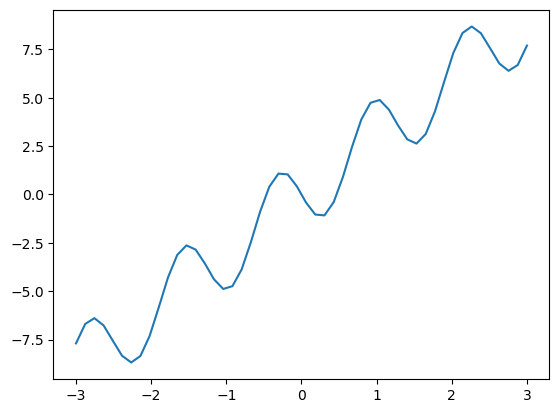

In [80]:
x = np.linspace(-3, 3)
y = 3*x - 2*np.sin(5*x)

plt.plot(x, y)

## Indexer un tableau

On peut indexer un tableau numpy de plusieurs façons : avec un entier, une tranche (slice que l'on fait avec les ```:```), un tableau d'entiers ou un tableau de booléens

Sur le tableau ci-dessous : 
- Extraire avec un indice simple le nombre ```0.14665455```
- Extraire ```0.90215908```, l'avant-dernier élément.
- Extraire avec une tranche ```0.31128493, 0.14665455, 0.09377272``` et ```0.14665455, 0.94734078, 0.45876301``` (un sur deux).
- Extraire les éléments $a_i$ tels que $b_i$ soit vrai ? tels que $b_i$ soit faux ? tels que $a_i>.6$.
- Créer le tableau $d_i = a_{c_i}$.
- Créer le tableau $e_i = a_{i+1} - a_i$.

In [66]:
a = np.array([0.18671948, 0.31128493, 0.14665455, 0.09377272, 0.94734078,
       0.40556268, 0.45876301, 0.26474838, 0.90215908, 0.11927916])

b = np.array([ True,  True,  True, False, False,  True,  True,  True,  True,
        True])

c = np.array([1,3,5])

In [68]:
print(a[2])
print(a[-2])
print(a[1:4])
print(a[2:8:2])

print(a[b])
print(a[~b])
print(a[a>0.6])

print(a[c])

print(a[1:] - a[:-1])

0.14665455
0.90215908
[0.31128493 0.14665455 0.09377272]
[0.14665455 0.94734078 0.45876301]
[0.18671948 0.31128493 0.14665455 0.40556268 0.45876301 0.26474838
 0.90215908 0.11927916]
[0.09377272 0.94734078]
[0.94734078 0.90215908]
[0.31128493 0.09377272 0.40556268]
[ 0.12456545 -0.16463038 -0.05288183  0.85356806 -0.5417781   0.05320033
 -0.19401463  0.6374107  -0.78287992]


## Opérations sur les tableaux

* On considère $N=1\,000\,000$ points tirés aléatoirement sur une distribution uniforme entre 0 et 1. Calculer la moyenne, l'écart type, le maximum et le minimum de cette distribution.

In [41]:
a = np.random.rand(1_000_000)
print(a.mean())
print(a.std())
print(a.min())
print(a.max())

0.49959234295614485
0.2887571740308912
1.256938543248154e-07
0.9999993393786111


* On considère $N=1\,000$ points tirés aléatoirement sur une distribution uniforme entre 0 et 1. La moyenne, l'écart type, le maximum et le minimum de cette distribution sont des variables aléatoires. Calculer l'écart type de ces variables aléatoires en effectuant l'opération $M=100\,000$ fois. On commencera par créer un tableau de taille $N\times M$  contenant tous les tirages. Il faudra utiliser l'option ```axis``` des fonctions/méthodes numpy.

In [52]:
a = np.random.rand(1000, 100000)

In [53]:
print(a.mean(axis=0).std())
print(a.std(axis=0).std())
print(a.min(axis=0).std())
print(a.max(axis=0).std())

0.009161752106707829
0.004089964500630494
0.0010024367631060497
0.001001997550628514


## Types de données

- On considère le code suivant. Que se passe-t-il ? Pourquoi ?

In [40]:
a = np.array([1, 2, 4])
a[1] = 3.14
print(a)

[1 3 4]


Le type des données est fixé à la création. Il ne peut pas changer. Python pourrait donner une erreur mais il ne le fait pas !

- Calculer $3^{523}$ en utilisant python natif (```a = 3```) et un tableau numpy ```a = np.array([3])```. Que se passe-t-il ? Pourquoi ? Quel est le type de données dans le tableau ? Comment calculer approximativement $3^{523}$ avec numpy ?

In [7]:
import numpy as np

print(np.array([3])**523)
print(3**523)
print((3**523)%(2**64))

[5212819990241684475]
3423073452740484444185871911899602725221203455270744842679540287347185276727273132942177916168305742042139914387548047311979428676773826478795315576685342309045973774539407636175685406227498787581128475121030114571406089675825372214963526316006648827
5212819990241684475


En Python les entiers sont de tailles infinies. Par contre, avec numpy, la taille est finie. Ils sont stockés sous forme d'entier par défaut en 64bits et le calcul se fait modulo 64 bits

In [8]:
np.array([3.])**523

array([3.42307345e+249])

## Conditions sur un tableau

On souhaite vérifier que $\cos^2 + \sin^2 = 1$ en prenant avec 10000 points aléatoirement entre 0 et $2\pi$. Pourquoi le code suivant ne fonctionne pas ? Comment le faire fonctionner !

In [11]:
import numpy as np
from math import *

x = np.random.rand(0, 1)*2*np.pi

if cos(x)**2 + sin(x**2)==1:
    print('Le test fonctionne')
else:
    print('Ça ne fonctionne pas')

TypeError: only length-1 arrays can be converted to Python scalars

Lorsque l'on utilise numpy : 
- Il ne faut pas utiliser le module math
- Il n'est pas possible de faire un test sur un tableau de booléens

In [12]:
import numpy as np
from math import *

x = np.random.rand(0, 1)*2*np.pi

if np.all(np.cos(x)**2 + np.sin(x**2)==1):
    print('Le test fonctionne')
else:
    print('Ça ne fonctionne pas')

Le test fonctionne


## Vitesse d'execution de numpy 

On considère le code suivant qui crée un tableau et une liste d'un millions de nombre alétoire entre 0 et 1. En utilisant la fonction %timeit, combien de temps faut-il pour calculer ```a**2``` le tableau contenant les carrés des éléments de ```a``` ? Justifier l'ordre de grandeur de ce nombre.
Écrire une fonction python qui à partir d'une liste renvoie une nouvelle liste contenant les carrés des nombres. Calculer les temps d'execution de cette fonction ? Commenter.

In [95]:
a = np.random.rand(1_000_000)
b = list(a)

In [21]:
%timeit a**2

240 μs ± 57.5 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [22]:
# En ordre de grandeur, un CPU à 5 GHz effectue met 200 ns par opération. 

In [27]:
def carre1(x):
    return [elm**2 for elm in x]

def carre2(x):
    output = []
    for elm in x:
        output.append(elm**2)
    return output

def carre2bis(x):
    output = []
    for i in range(len(x)):
        output.append(x[i]**2)
    return output

def carre3(x):
    output = np.empty(len(x))
    for i in range(len(x)):
        output[i] = x[i]**2
    return output

%timeit carre1(b)
%timeit carre2(b)
%timeit carre2bis(b)
%timeit carre3(b)

61.6 ms ± 24.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
81.4 ms ± 30.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
88.3 ms ± 36.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
101 ms ± 37.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Les boucles for sont toujours plus lentes. La list comprehension est aussi une boucle for. L'utilisation de tableaux n'améliore pas la vitesse s'il y a une boucle for.

## Polymorphisme et fonction compatible avec les tableaux numpy 

Le polymorphisme est la possibilité pour une fonction d'utiliser des arguments de types différents. 

* On considère la fonction suivante. Donner au moins 5 types de données pour lesquels cette fonction ne donne pas d'erreur ?

In [29]:
def f(x, y):
    return x + y

In [81]:
f(1, 2) # Entiers
f(2.3, 4.5) # float
f(2.3 + 2J, 4.5 - 1.3J) # complex
f([1, None, 3] , ["Bonjour"]) # Concaténation de liste
f(np.array([1, 2, 3]) , np.array([1, 2, 3])) # Additions de tableaux
f('Bonjour', 'Au revoir')

'BonjourAu revoir'

* On considère les fonctions suivantes. Pourquoi la première fonctionne sur des tableaux et pas la seconde ? Que fait la fonction np.vectorize ? Comment l'utiliser pour résoudre le problème ? Est-ce rapide ?

In [36]:
def gaussienne(x):
    return np.exp(-x**2/2)

def triangle(x):
    if x<-1:
        return 0.
    elif x<0:
        return 1+x
    elif x<1:
        return 1-x
    else:
        return 0.

x = np.linspace(-2, 2)
print(gaussienne(x))
print(triangle(x))

[0.13533528 0.15880684 0.18511146 0.21434003 0.24653535 0.28168324
 0.31970449 0.36044779 0.40368434 0.44910445 0.4963165  0.54484879
 0.59415419 0.64361811 0.69256932 0.74029388 0.78605145 0.82909386
 0.86868502 0.90412167 0.934754   0.96000544 0.97939068 0.99253116
 0.99916736 0.99916736 0.99253116 0.97939068 0.96000544 0.934754
 0.90412167 0.86868502 0.82909386 0.78605145 0.74029388 0.69256932
 0.64361811 0.59415419 0.54484879 0.4963165  0.44910445 0.40368434
 0.36044779 0.31970449 0.28168324 0.24653535 0.21434003 0.18511146
 0.15880684 0.13533528]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [37]:
triangle_vec = np.vectorize(triangle)

In [39]:
a = np.random.rand(1_000_000)
%timeit gaussienne(a)
%timeit triangle_vec(a)

1.51 ms ± 636 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
133 ms ± 49.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# C'est très pratique, mais ce n'est pas rapide car il y a une boucle for en python. 

## Tri d'un tableau

* Comment trier un tableau ? Est-ce que le tri se fait en place ?
* Que fait la méthode ```argsort``` ?
* Voici une liste d'élève et de notes. Créer un tableau avec les élèves par ordre décroissant des notes

In [ ]:
liste_eleves = [
    "Maël", "Rose", "Louis", "Alba", "Alice",
    "Raphaël", "Jules", "Adam", "Emma", "Léo",
    "Léon", "Gabriel", "Jade", "Noah", "Ambre",
    "Arthur", "Romy", "Adèle", "Louise", "Alma"
]

listes_notes = np.random.rand(len(liste_eleves))*20

In [1]:
liste_eleves[-listes_notes.argsort()]

NameError: name 'liste_eleves' is not defined

## Tableau numpy et espace mémoire

On considère le code suivant. Justifier la sortie !

In [92]:
a = np.array([0.18671948, 0.31128493, 0.14665455, 0.09377272, 0.94734078,
       0.40556268, 0.45876301, 0.26474838, 0.90215908, 0.11927916])
b = a[1:3]
c = 3*a
d = a[a<.8]
e = a[[1, 4, 6, 3, 4, 6]]
def f(a):
    a[6] = 9.3
    return a

a[0] = 1.2
b[1] = 4.5
c[2] = 5.6
d[3] = 3.5
e[5] = 7.4
f(a)
print(a)

[1.2        0.31128493 4.5        0.09377272 0.94734078 0.40556268
 9.3        0.26474838 0.90215908 0.11927916]
